In [37]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris, make_classification, make_moons, fetch_lfw_people
from sklearn.svm import LinearSVC, SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, classification_report
from sklearn.decomposition import PCA


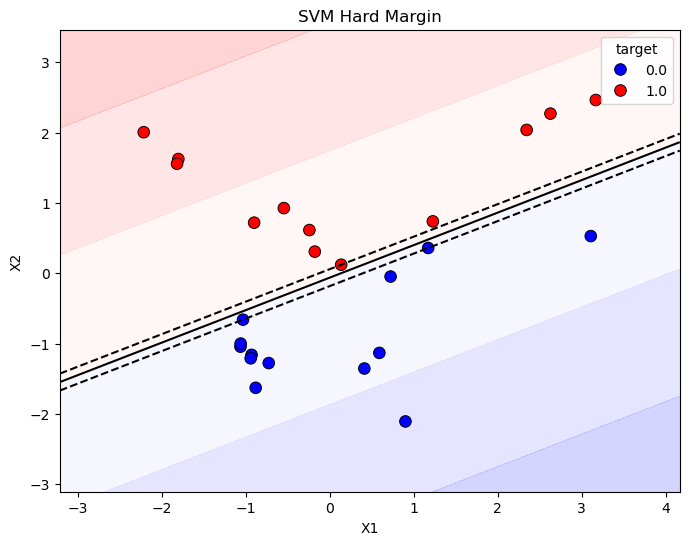

In [2]:
X, y = make_classification(
    n_classes=2, n_features=2, n_informative=2, n_redundant=0,
    n_samples=25, random_state=15,
)
data = pd.DataFrame(
    data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'],
)
model = SVC(C=1e6, kernel='linear')
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', 
    response_method='decision_function',
    cmap='bwr', 
    alpha=0.2,
    ax=ax
)

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour',              
    response_method='decision_function',
    levels=[-1, 0, 1],                   
    linestyles=['--', '-', '--'],        
    colors='k',                          
    ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('SVM Hard Margin')
plt.show()

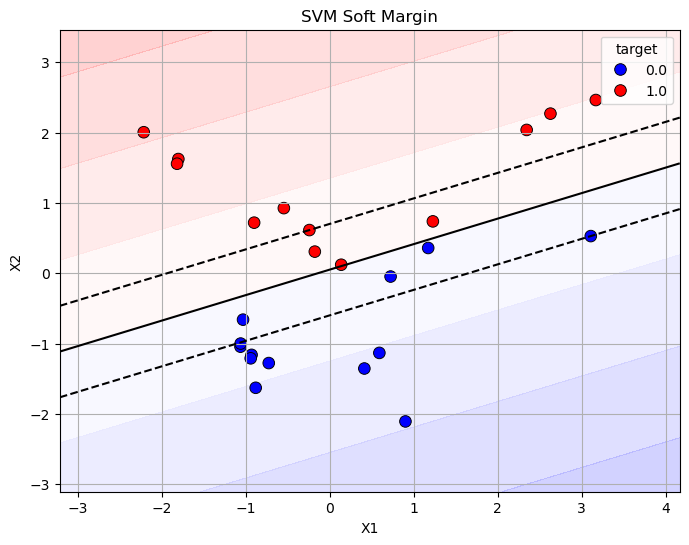

In [3]:
model = SVC(C=1, kernel='linear')
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', 
    response_method='decision_function',
    cmap='bwr', 
    alpha=0.2,
    ax=ax
)

DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour',              
    response_method='decision_function',
    levels=[-1, 0, 1],                   
    linestyles=['--', '-', '--'],        
    colors='k',                          
    ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('SVM Soft Margin')
plt.grid()
plt.show()

In [4]:
model.support_vectors_.shape

(8, 2)

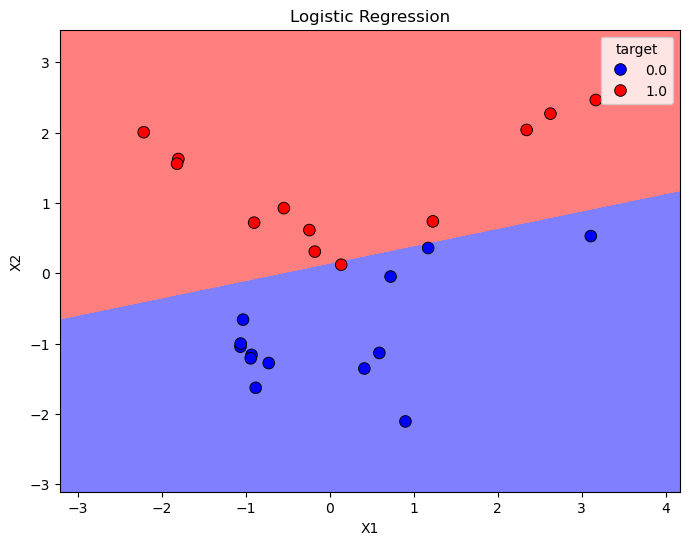

In [5]:
model = LogisticRegression()
model.fit(X,y)

plt.figure(figsize=(8,6))
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contourf', response_method='predict_proba',
    levels=1, cmap ='bwr', ax=ax
)
sns.scatterplot(
    data=data, x='X1', y='X2', hue='target', 
    palette=['blue', 'red'], s=70, edgecolor='k', ax=ax
)
plt.title('Logistic Regression')
plt.show()

Hinge loss is a convex loss function used primarily in training Support Vector Machines (SVMs) for maximum-margin classification, penalizing incorrect predictions and predictions that fall within the classification margin.$$L(w, b) = \max\left(0, 1 - y_i(w \cdot x_i + b)\right)$$Where $y_i \in \{-1, 1\}$ is the true class label, and $w \cdot x_i + b$ is the unthresholded model prediction (or raw margin score).

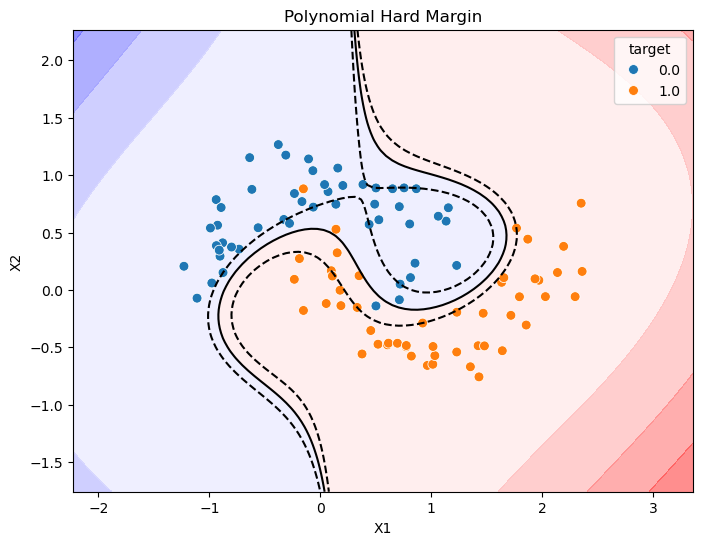

In [6]:
X, y = make_moons(n_samples=100, shuffle=True, noise=0.2, random_state=26)
data = pd.DataFrame(data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'])
model = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearSVC(C=50, loss='hinge', max_iter=50000))
])
model.fit(X,y)

plt.figure(figsize=(8,6))
DecisionBoundaryDisplay.from_estimator(
    model, X, 
    response_method='decision_function', plot_method='contourf',
    cmap='bwr', ax= plt.gca(), alpha=0.5,
)
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour', response_method='decision_function',
    levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k',                          
    ax=plt.gca(),
)
plt.title('Polynomial Hard Margin')
sns.scatterplot(data=data, x='X1', y='X2', hue='target', s=50)
plt.show()

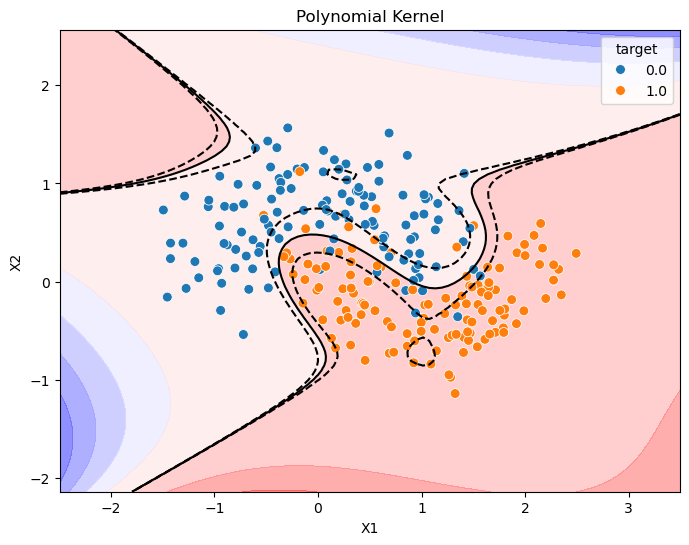

In [7]:
# Kernel 

X, y = make_moons(n_samples=250, shuffle=True, noise=0.3, random_state=26)
data = pd.DataFrame(data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'])
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='poly', C=10, degree=5, coef0=1))
])
model.fit(X,y)

plt.figure(figsize=(8,6))
DecisionBoundaryDisplay.from_estimator(
    model, X, 
    response_method='decision_function', plot_method='contourf',
    cmap='bwr', ax= plt.gca(), alpha=0.5,
)
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour', response_method='decision_function',
    levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k',                          
    ax=plt.gca(),
)
plt.title('Polynomial Kernel')
sns.scatterplot(data=data, x='X1', y='X2', hue='target', s=50)
plt.show()

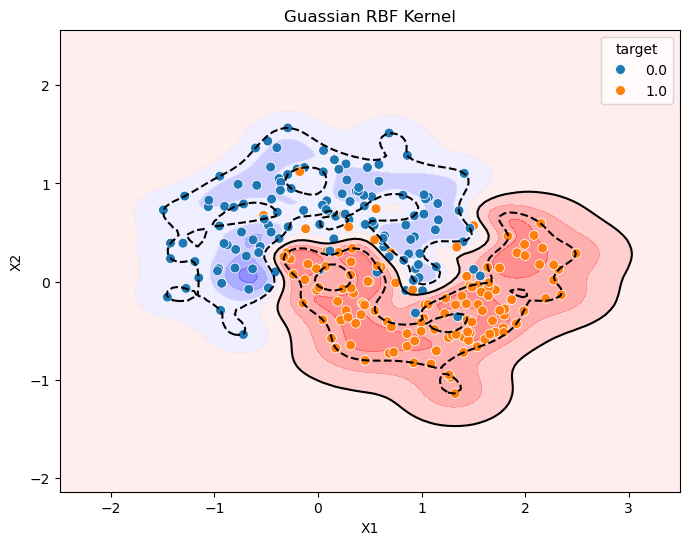

In [8]:
# rbf Kernel 

X, y = make_moons(n_samples=250, shuffle=True, noise=0.3, random_state=26)
data = pd.DataFrame(data=np.column_stack((X,y)), columns=['X1', 'X2', 'target'])
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', gamma=5, C=10))
])
model.fit(X,y)

plt.figure(figsize=(8,6))
DecisionBoundaryDisplay.from_estimator(
    model, X, 
    response_method='decision_function', plot_method='contourf',
    cmap='bwr', ax= plt.gca(), alpha=0.5,
)
DecisionBoundaryDisplay.from_estimator(
    model, X,
    plot_method='contour', response_method='decision_function',
    levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k',                          
    ax=plt.gca(),
)
plt.title('Guassian RBF Kernel')
sns.scatterplot(data=data, x='X1', y='X2', hue='target', s=50)
plt.show()

# DataSet

In [9]:
df = pd.read_csv('C:/Users/hp/Downloads/bank/bank.csv',sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [11]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


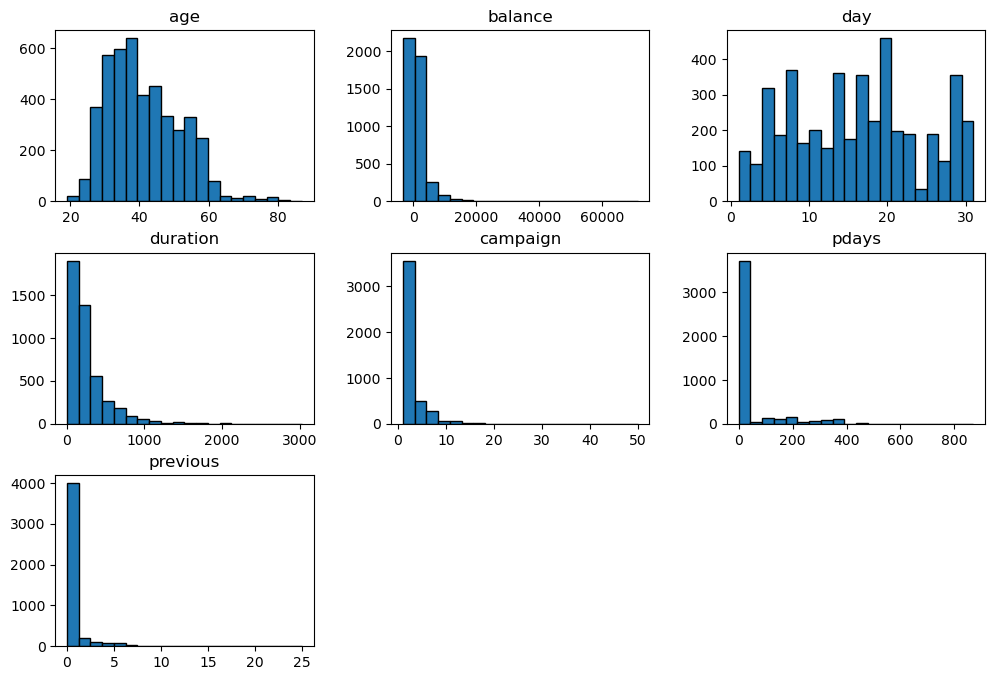

In [12]:
numeric_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df[numeric_cols].hist(grid=False, figsize=(12,8), bins=20, edgecolor='k')
plt.title('Numeric Features')
plt.show()

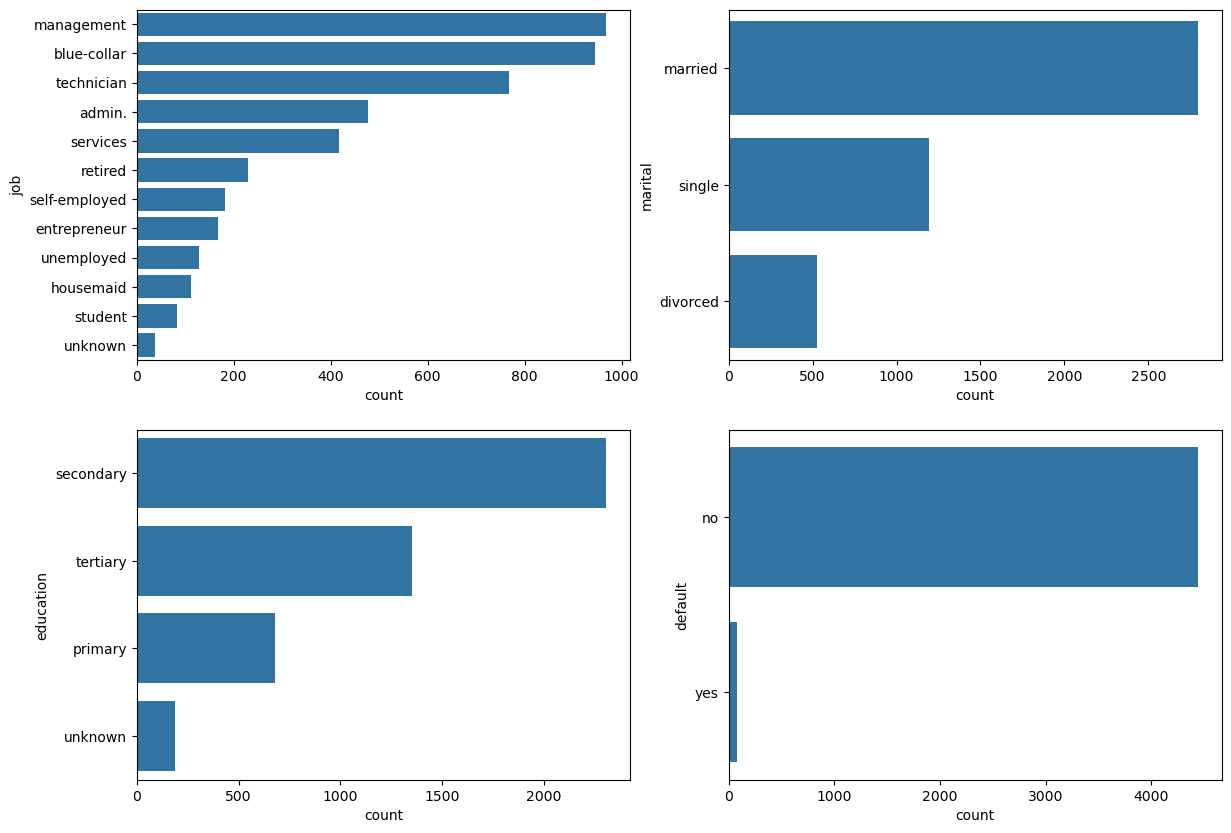

In [13]:
fig, ax = plt.subplots(2,2, figsize=(14,10))
ax = ax.flatten()
for idx, value in enumerate(cat_cols[:4]):
    sns.countplot(data=df[cat_cols], y=value, ax=ax[idx], orient='h', order=df[value].value_counts().index)
plt.show()

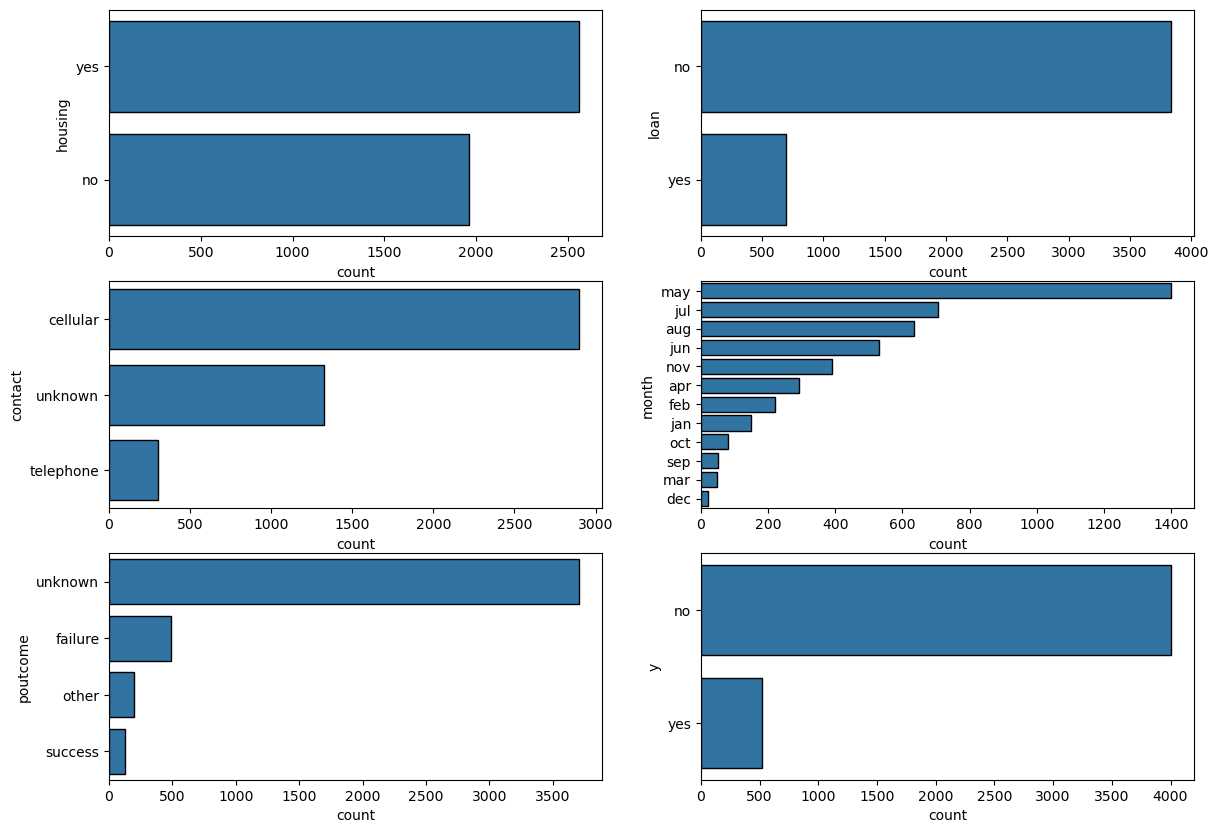

In [14]:
fig, ax = plt.subplots(3,2, figsize=(14,10))
ax = ax.flatten()
for idx, value in enumerate(cat_cols[4:]):
    sns.countplot(
        data=df[cat_cols], y=value,
        ax=ax[idx], orient='h',
        order=df[value].value_counts().index,
        edgecolor='k'
    )
plt.show()

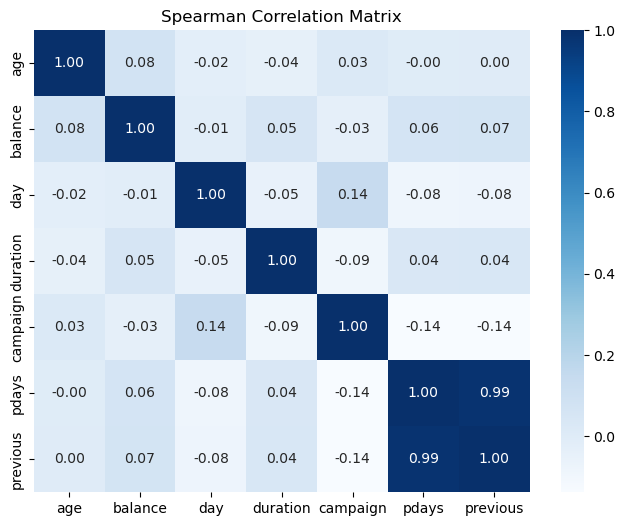

In [15]:
corr = df[numeric_cols].corr(method='spearman')

plt.figure(figsize=(8,6))
plt.title('Spearman Correlation Matrix')
sns.heatmap(data=corr, cmap='Blues', annot=True, fmt='.2f')
plt.show()

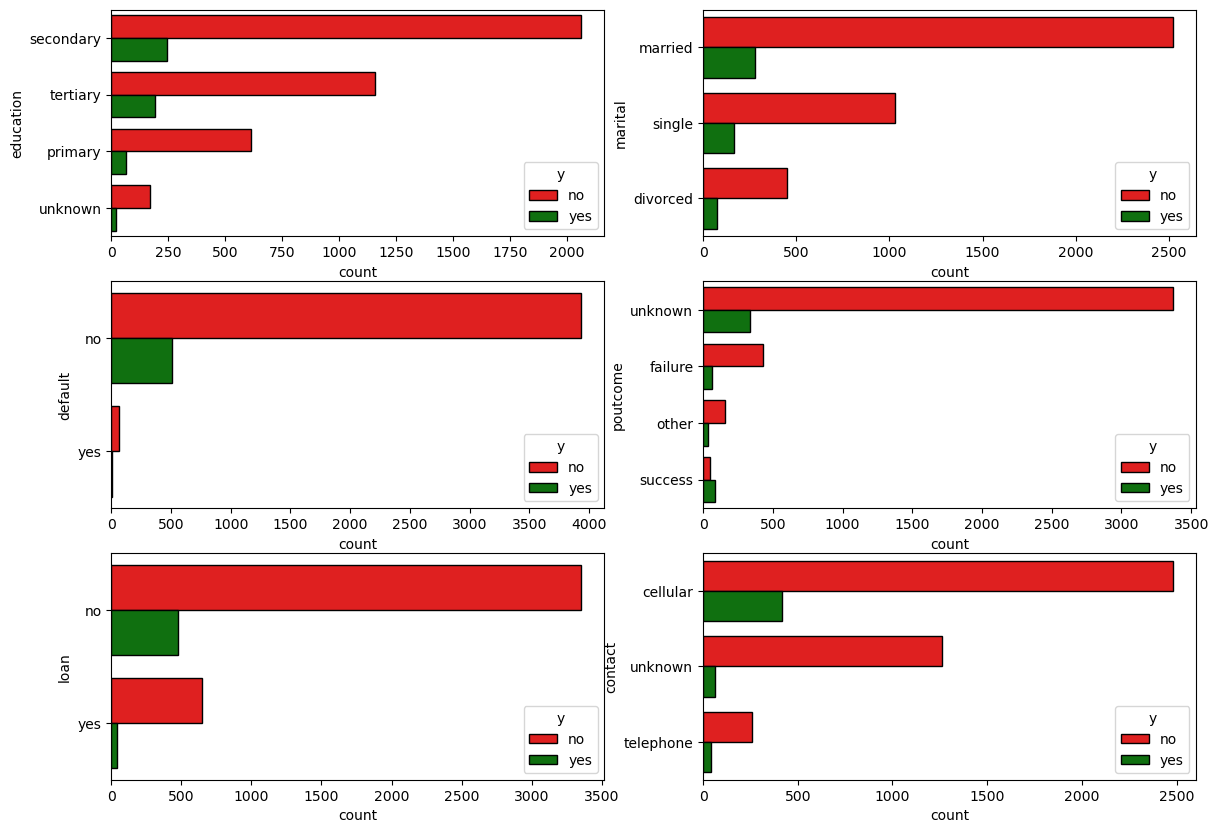

In [16]:
columns = ['education', 'marital', 'default', 'poutcome', 'loan', 'contact']

fig, ax = plt.subplots(3,2, figsize=(14,10))
ax = ax.flatten()
for idx, value in enumerate(columns):
    sns.countplot(
        data=df, y=value, hue='y',
        ax=ax[idx], orient='h', palette=['red', 'green'],
        order=df[value].value_counts().index,
        edgecolor='k'
    )
plt.show()

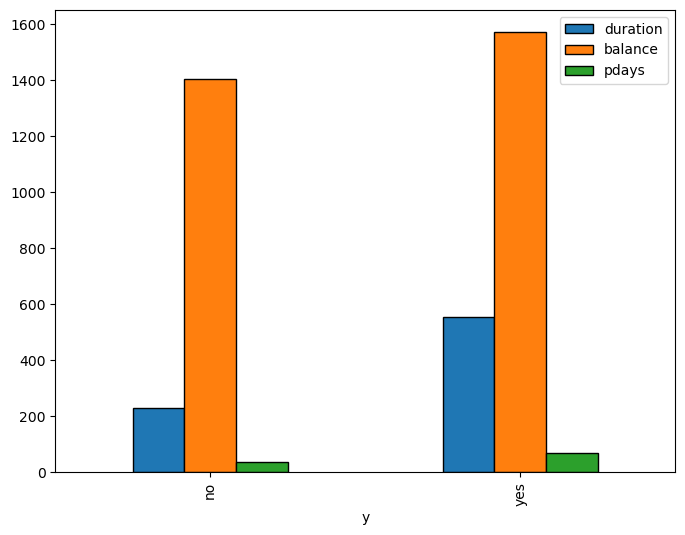

In [17]:
df.groupby('y')[['duration', 'balance', 'pdays']].mean().plot(
    kind='bar',
    figsize=(8, 6),
    edgecolor='k'
)
plt.show()


In [18]:
df['pdays'] = pd.cut(
    df['pdays'],
    bins=[-2, -1, 7, 30, 90, df['pdays'].max()],
    labels=['never', 'recent_week', 'recent_month', 'last_quarter', 'older_contact'],
)
df['pdays'].value_counts()

pdays
never            3705
older_contact     745
last_quarter       56
recent_week        14
recent_month        1
Name: count, dtype: int64

In [19]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns='y')
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, 
    random_state=26, stratify=y
)
sfolds = StratifiedKFold(n_splits=6, shuffle=True, random_state=26)

preprocessing_pipeline = make_pipeline(
    FunctionTransformer(func=np.log1p, validate=True, feature_names_out='one-to-one'),
    StandardScaler()
)

job = [
    'unknown', 'unemployed',
    'housemaid', 'student',
    'retired', 'services',
    'technician', 'self-employed',  
    'entrepreneur', 'management',
    'admin.', 'blue-collar',
]

education = [
    'unknown', 'primary', 'tertiary', 'secondary'
]

poutcome = [
    'unknown', 'failure', 'other', 'success'
]
pdays = [
    'never', 'recent_week' , 'recent_month', 'last_quarter', 'older_contact'
]
col_transform = ColumnTransformer([
    ('log_z_scaling', preprocessing_pipeline, ['campaign', 'previous', 'duration']),
    ('scaling', StandardScaler(), ['age', 'balance' , 'day']),
    ('nominal', OneHotEncoder(sparse_output=False, drop='first',handle_unknown='ignore'),  ['marital', 'contact','default', 'housing', 'loan', 'month']),
    ('ordinal', OrdinalEncoder(categories=[job, education, poutcome, pdays]), ['job', 'education', 'poutcome', 'pdays'])
],
                                  remainder='drop'
                                 )
                                 

pipeline = Pipeline([
    ('preprocess', col_transform),
    ('model', SVC(kernel='rbf', class_weight='balanced'))
])

param_grid = {
    'model__C': [0.001, 0.1, 10],
    'model__gamma': ['scale', 0.001, 1,5]
}

grid_search = GridSearchCV(pipeline, param_grid, scoring='recall', cv=sfolds)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__C': [0.001, 0.1, ...], 'model__gamma': ['scale', 0.001, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('log_z_scaling', ...), ('scaling', ...), ...]"


In [20]:
grid_search.best_score_

np.float64(0.8467218771566598)

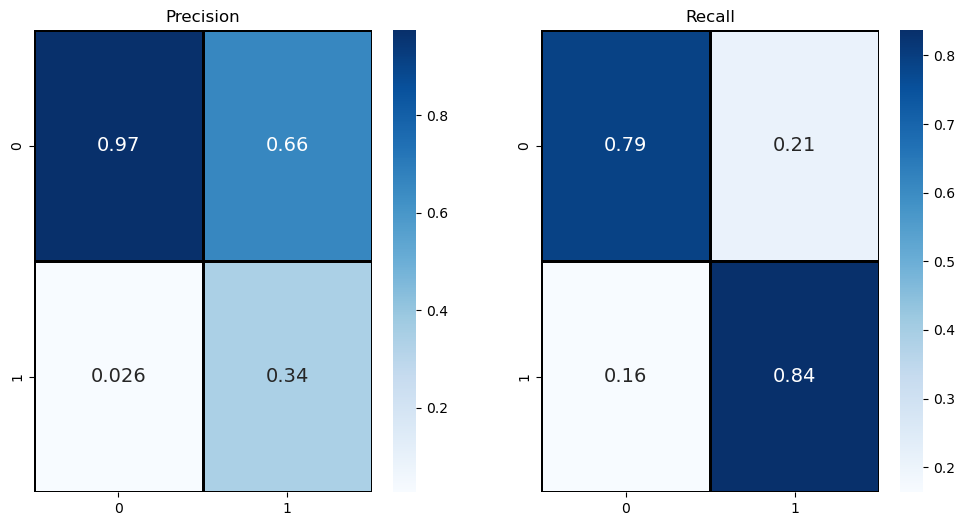

In [21]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, normalize='pred')
cm2 = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(1,2,figsize=(12,6))
sns.heatmap(data=cm, cmap='Blues', annot=True, annot_kws={'size': 14}, linecolor='black', linewidths=2,ax=ax[0])
sns.heatmap(data=cm2, cmap='Blues', annot=True, annot_kws={'size': 14}, linecolor='black', linewidths=2,ax=ax[1])
ax[1].set_title('Recall')
ax[0].set_title('Precision')
plt.show()

In [22]:
pd.DataFrame(
    data=classification_report(
        y_test, y_pred, target_names=['Deposit', 'Not Deposit'],
        output_dict=True
    )
)

,Deposit,Not Deposit,accuracy,macro avg,weighted avg
precision,0.973846,0.341176,0.79558,0.657511,0.901142
recall,0.790262,0.836538,0.79558,0.813400,0.795580
f1-score,0.872502,0.484680,0.79558,0.678591,0.827934
support,801.000000,104.000000,0.79558,905.000000,905.000000


C:\Users\hp\miniconda3\envs\pydata-book\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


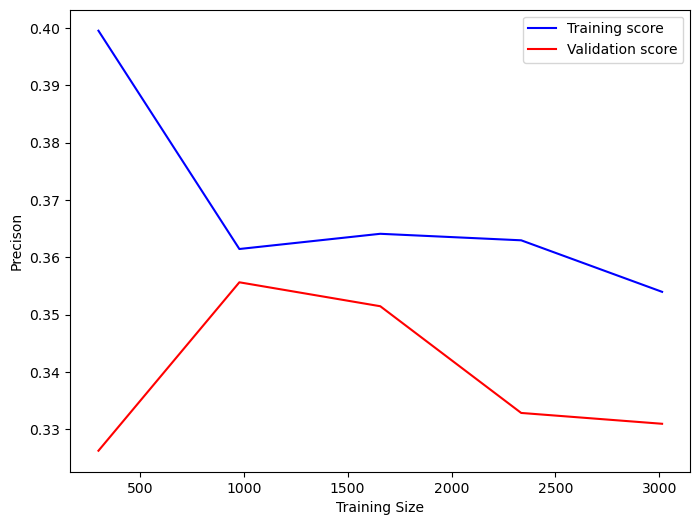

In [23]:
train_size, train_scores, test_scores = learning_curve(
    pipeline, X_train, y_train, cv=sfolds,
    scoring='precision',
)
plt.figure(figsize=(8,6))
plt.plot(train_size, train_scores.mean(axis=1), color='blue', label='Training score')
plt.plot(train_size, test_scores.mean(axis=1), color='red', label='Validation score')
plt.ylabel('Precison')
plt.xlabel('Training Size')
plt.legend()
plt.show()

In [54]:
df['y'].value_counts()

y
0    4000
1     521
Name: count, dtype: int64